# Modelo de regresion lineal usando pandas y python

## 1. Carga de datos

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

url = "https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv"
datos = pd.read_csv(url)

print("Primeras filas de nuestros datos:")
print(datos.head())

Primeras filas de nuestros datos:
   fips  TOT_POP    0-9  0-9 y/o % of total pop  19-Oct  \
0  1001    55601   6787               12.206615    7637   
1  1003   218022  24757               11.355276   26913   
2  1005    24881   2732               10.980266    2960   
3  1007    22400   2456               10.964286    2596   
4  1009    57840   7095               12.266598    7570   

   10-19 y/o % of total pop  20-29  20-29 y/o % of total pop  30-39  \
0                 13.735364   6878                 12.370281   7089   
1                 12.344167  23579                 10.814964  25213   
2                 11.896628   3268                 13.134520   3201   
3                 11.589286   3029                 13.522321   3113   
4                 13.087828   6742                 11.656293   6884   

   30-39 y/o % of total pop  ...  COPD_number  diabetes_prevalence  \
0                 12.749771  ...         3644                 12.9   
1                 11.564429  ...        1469

## 2. EDA

In [6]:
datos_numericos = pd.get_dummies(datos, drop_first=True)

datos_limpios = datos_numericos.dropna()

variable_objetivo = "CKD_number" 

X = datos_limpios.drop(variable_objetivo, axis=1)
y = datos_limpios[variable_objetivo]

# 80% para entrenar y 20% para hacer pruebas
X_entreno, X_prueba, y_entreno, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Modelo de regresión Lineal vs Lasso

In [7]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_squared_error

# Regresión Lineal Clásica
modelo_basico = LinearRegression()
modelo_basico.fit(X_entreno, y_entreno)
predicciones_basicas = modelo_basico.predict(X_prueba)

r2_basico = r2_score(y_prueba, predicciones_basicas)
print(f"R2 del Modelo Básico: {r2_basico}")

# Regresión Lasso
modelo_lasso = Lasso(alpha=1.0, max_iter=5000)
modelo_lasso.fit(X_entreno, y_entreno)
predicciones_lasso = modelo_lasso.predict(X_prueba)

r2_lasso = r2_score(y_prueba, predicciones_lasso)
print(f"R2 del Modelo Lasso (alpha=1.0): {r2_lasso}")

R2 del Modelo Básico: 0.9987213708589636
R2 del Modelo Lasso (alpha=1.0): 0.9990778110307872


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.593e+07, tolerance: 1.754e+07
  model = cd_fast.enet_coordinate_descent(


## 4.  Cambio del coeficiente de determinación ($R^2$)

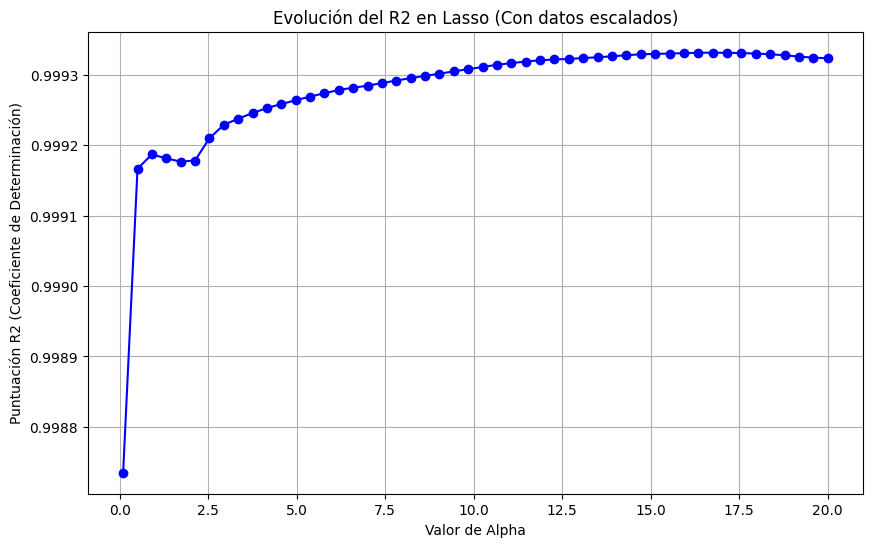

In [9]:
from sklearn.preprocessing import StandardScaler
import numpy as np

escalador = StandardScaler()
# Escalar los datos para que no me devuelva un ConvergenceWarning
X_entreno_escalado = escalador.fit_transform(X_entreno)
# Solo transformamos los datos de prueba
X_prueba_escalada = escalador.transform(X_prueba)

valores_alpha = np.linspace(0.1, 20, 50)
resultados_r2 = []

# Bucle para probar cada valor de alpha
for alfa in valores_alpha:
    modelo_temporal = Lasso(alpha=alfa, max_iter=10000) 

    modelo_temporal.fit(X_entreno_escalado, y_entreno)
    prediccion_temporal = modelo_temporal.predict(X_prueba_escalada)
    
    # Guardar el resultado del R2
    resultado = r2_score(y_prueba, prediccion_temporal)
    resultados_r2.append(resultado)

plt.figure(figsize=(10, 6))
plt.plot(valores_alpha, resultados_r2, marker='o', color='b')
plt.title("Evolución del R2 en Lasso (Con datos escalados)")
plt.xlabel("Valor de Alpha")
plt.ylabel("Puntuación R2 (Coeficiente de Determinación)")
plt.grid(True)
plt.show()

## 5. Optimización del modelo

In [11]:
from sklearn.model_selection import GridSearchCV

# Hiperparámetros
parametros_a_probar = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0, 15.0, 20.0]}

modelo_para_optimizar = Lasso(max_iter=10000)

busqueda_inteligente = GridSearchCV(modelo_para_optimizar, parametros_a_probar, cv=5, scoring='r2')

# Entrenamiento con los datos escalados
busqueda_inteligente.fit(X_entreno_escalado, y_entreno)

mejor_modelo = busqueda_inteligente.best_estimator_

print("\nResultados de la Optimización")
print(f"El mejor valor de alpha encontrado fue: {busqueda_inteligente.best_params_['alpha']}")

predicciones_ganadoras = mejor_modelo.predict(X_prueba_escalada)

r2_final = r2_score(y_prueba, predicciones_ganadoras)
error_final = mean_squared_error(y_prueba, predicciones_ganadoras)

print(f"R2 del modelo optimizado: {r2_final}")
print(f"Error cuadrático medio final: {error_final}")


Resultados de la Optimización
El mejor valor de alpha encontrado fue: 5.0
R2 del modelo optimizado: 0.9992639844643774
Error cuadrático medio final: 14084.796792387944
